# Terrain-Aware Flight Planning

When planning airborne remote sensing over mountainous or hilly terrain, it's important
to account for terrain elevation. This notebook demonstrates how to use HyPlan's terrain
module to:

1. Download and query digital elevation models (DEMs)
2. Compute terrain profiles along flight lines
3. Assess altitude-above-ground-level (AGL) along a flight plan
4. Understand how terrain affects sensor GSD and swath width

**Note:** Terrain functions download DEM tiles from AWS on first use (~30 MB per 1x1 degree tile).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from hyplan.flight_line import FlightLine
from hyplan.sensors import AVIRIS3
from hyplan.terrain import generate_demfile, get_elevations, get_min_max_elevations
from hyplan.units import ureg

## 1. Define Flight Lines Over Mountainous Terrain

We'll create a flight line over the San Gabriel Mountains near Los Angeles,
where terrain ranges from ~300 m to over 3000 m.

In [2]:
fl = FlightLine.start_length_azimuth(
    lat1=34.15, lon1=-118.1,
    length=ureg.Quantity(50, "km"),
    az=45.0,  # Northeast across the mountains
    altitude_msl=ureg.Quantity(6000, "meter"),
    site_name="San Gabriel Mountains",
)

print(f"Flight line: {fl.site_name}")
print(f"  Start: ({fl.lat1:.4f}, {fl.lon1:.4f})")
print(f"  End:   ({fl.lat2:.4f}, {fl.lon2:.4f})")
print(f"  Altitude MSL: {fl.altitude_msl}")
print(f"  Heading: {fl.az12:.1f} deg")

Flight line: San Gabriel Mountains
  Start: (34.1500, -118.1000)
  End:   (34.4681, -117.7152)
  Altitude MSL: 6000 meter
  Heading: 45.0 degree deg


## 2. Download DEM and Extract Terrain Profile

Sample terrain elevation along the flight line to understand the AGL variation.

In [3]:
# Sample points along the flight line
coords = np.array(fl.geometry.coords)
lons = coords[:, 0]
lats = coords[:, 1]

# Densify to get more points along the track
n_points = 200
interp_fracs = np.linspace(0, 1, n_points)
interp_lats = np.interp(interp_fracs, np.linspace(0, 1, len(lats)), lats)
interp_lons = np.interp(interp_fracs, np.linspace(0, 1, len(lons)), lons)

# Generate DEM file covering the flight line extent
dem_file = generate_demfile(interp_lats, interp_lons)
print(f"DEM file: {dem_file}")

# Get terrain elevations
terrain_elev_m = get_elevations(interp_lats, interp_lons, dem_file)
print(f"Terrain elevation range: {terrain_elev_m.min():.0f} - {terrain_elev_m.max():.0f} m")

DEM file: /var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/hyplan/dem_cache/34.05_-118.20_34.57_-117.62.tif
Terrain elevation range: 234 - 2063 m


/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


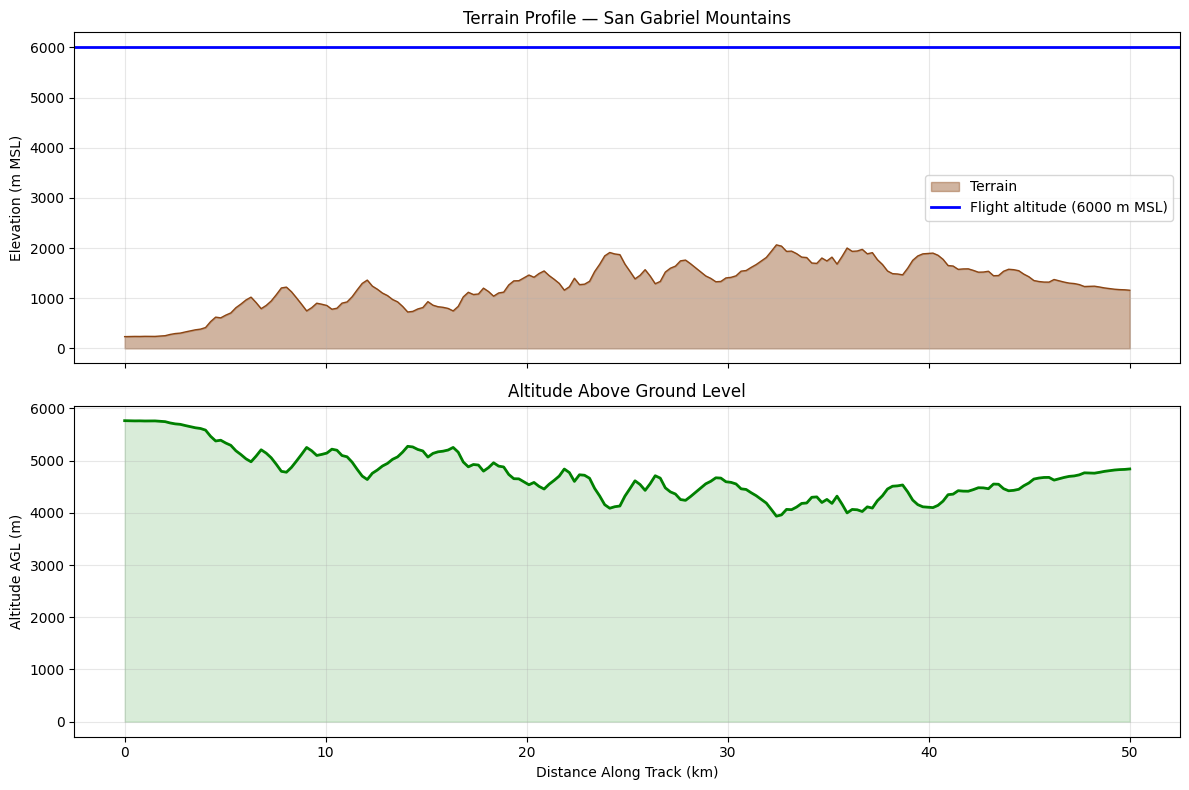

AGL range: 3937 - 5766 m


In [4]:
# Compute distances along track (approximate)
from pymap3d import vincenty

distances_km = [0]
for i in range(1, len(interp_lats)):
    d, _ = vincenty.vdist(interp_lats[i-1], interp_lons[i-1], interp_lats[i], interp_lons[i])
    distances_km.append(distances_km[-1] + d / 1000)
distances_km = np.array(distances_km)

# Plot terrain profile with flight altitude
flight_alt_m = fl.altitude_msl.to(ureg.meter).magnitude
agl_m = flight_alt_m - terrain_elev_m

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: altitude profile
ax1.fill_between(distances_km, 0, terrain_elev_m, color="saddlebrown", alpha=0.4, label="Terrain")
ax1.plot(distances_km, terrain_elev_m, color="saddlebrown", linewidth=1)
ax1.axhline(y=flight_alt_m, color="blue", linewidth=2, label=f"Flight altitude ({flight_alt_m:.0f} m MSL)")
ax1.set_ylabel("Elevation (m MSL)")
ax1.set_title(f"Terrain Profile — {fl.site_name}")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: AGL
ax2.plot(distances_km, agl_m, color="green", linewidth=2)
ax2.fill_between(distances_km, 0, agl_m, color="green", alpha=0.15)
ax2.set_xlabel("Distance Along Track (km)")
ax2.set_ylabel("Altitude AGL (m)")
ax2.set_title("Altitude Above Ground Level")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AGL range: {agl_m.min():.0f} - {agl_m.max():.0f} m")

## 3. Terrain Impact on Sensor Performance

Because GSD and swath width depend on altitude AGL, terrain variation causes these
to change along the flight line. High terrain means lower AGL, finer GSD, but
narrower swath.

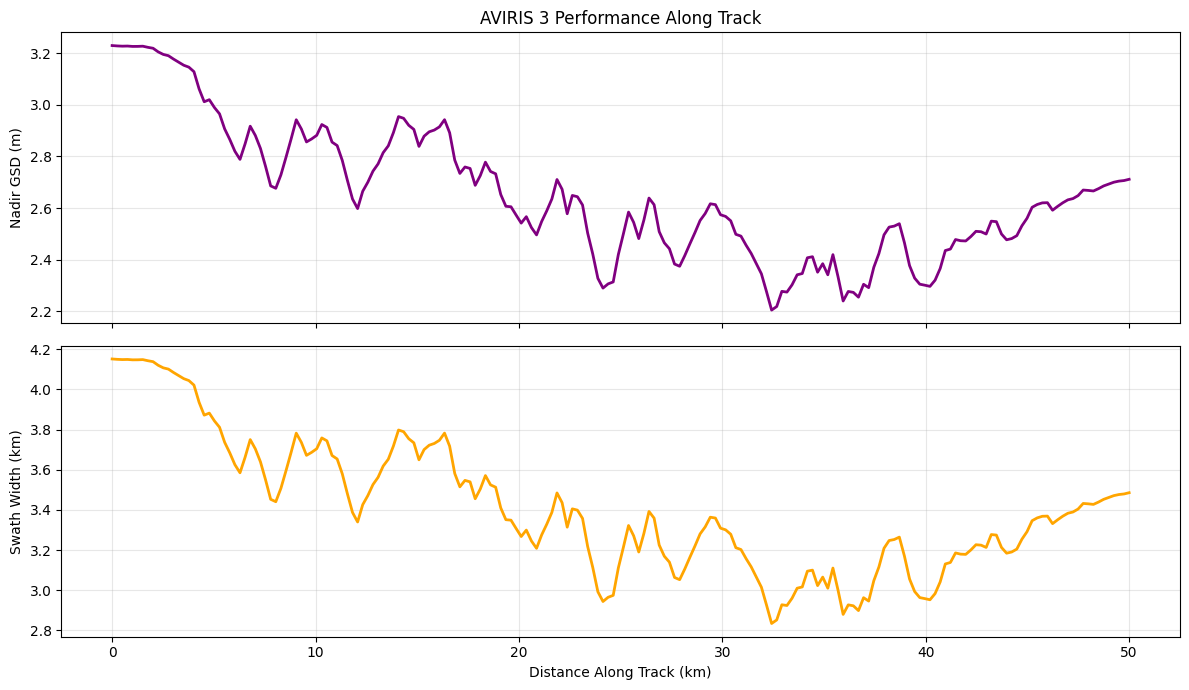

GSD range: 2.2 - 3.2 m
Swath width range: 2.83 - 4.15 km


In [5]:
sensor = AVIRIS3()

# Compute GSD and swath width at each point along the track
gsd_m = np.array([
    sensor.ground_sample_distance(ureg.Quantity(agl, "meter")).to(ureg.meter).magnitude
    for agl in agl_m
])

swath_m = np.array([
    sensor.swath_width(ureg.Quantity(agl, "meter")).to(ureg.meter).magnitude
    for agl in agl_m
])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(distances_km, gsd_m, color="purple", linewidth=2)
ax1.set_ylabel("Nadir GSD (m)")
ax1.set_title(f"{sensor.name} Performance Along Track")
ax1.grid(True, alpha=0.3)

ax2.plot(distances_km, swath_m / 1000, color="orange", linewidth=2)
ax2.set_xlabel("Distance Along Track (km)")
ax2.set_ylabel("Swath Width (km)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GSD range: {gsd_m.min():.1f} - {gsd_m.max():.1f} m")
print(f"Swath width range: {swath_m.min()/1000:.2f} - {swath_m.max()/1000:.2f} km")

## 4. Choosing a Flight Altitude

Compare different flight altitudes to find one that maintains a target GSD
even over the highest terrain.

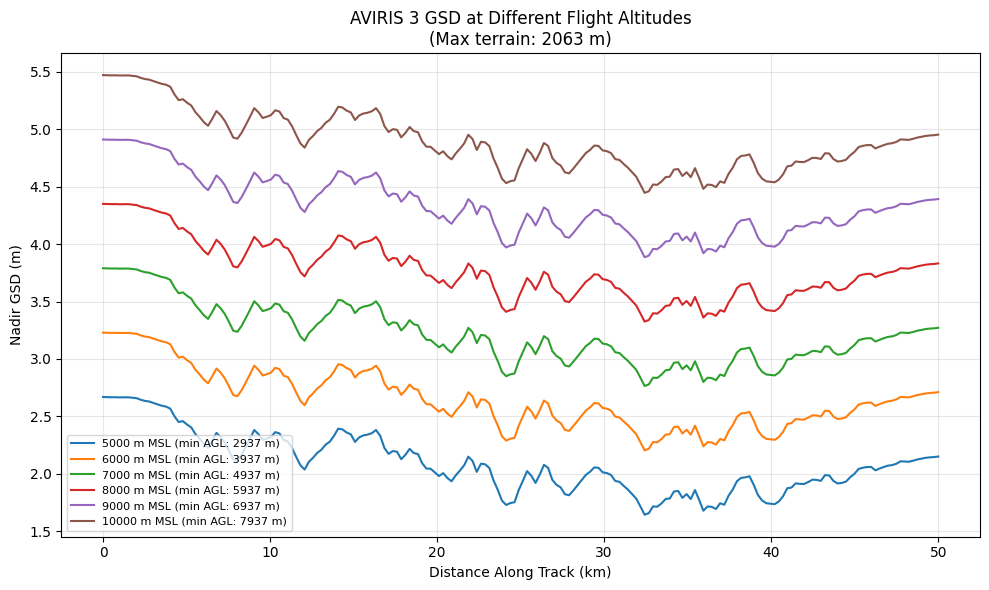

In [6]:
altitudes_msl = [5000, 6000, 7000, 8000, 9000, 10000]
max_terrain = terrain_elev_m.max()

fig, ax = plt.subplots(figsize=(10, 6))

for alt in altitudes_msl:
    agl_profile = alt - terrain_elev_m
    # Skip if altitude is below terrain
    if np.any(agl_profile <= 0):
        continue
    gsd_profile = np.array([
        sensor.ground_sample_distance(ureg.Quantity(a, "meter")).to(ureg.meter).magnitude
        for a in agl_profile
    ])
    ax.plot(distances_km, gsd_profile, label=f"{alt} m MSL (min AGL: {agl_profile.min():.0f} m)")

ax.set_xlabel("Distance Along Track (km)")
ax.set_ylabel("Nadir GSD (m)")
ax.set_title(f"{sensor.name} GSD at Different Flight Altitudes\n(Max terrain: {max_terrain:.0f} m)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()